# Figure 3d - Normalized probabilities for each Omi32 mutation at each mutational step for the 'weak' models (affinity-only, antigen capture, and competitive capture)

Loading mutation order probability data...

Global vmax for colorbar: 0.392

Main heatmap:
  Canvas size: 3.75 × 1.25 inches
  Total figure size: 4.55 × 1.77 inches
  At 2000 DPI: 9100 × 3550 pixels

✓ Main heatmap saved successfully!

Colorbar:
  Canvas size: 0.075 × 1.25 inches
  Total figure size: 0.47 × 1.77 inches
  At 2000 DPI: 950 × 3550 pixels

✓ Colorbar saved successfully!


/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_3418/823531196.py:168: UserWarning: Adding colorbar to a different Figure <Figure size 910x355 with 3 Axes> than <Figure size 95x355 with 1 Axes> which fig.colorbar is called on.
  cbar = cbar_fig.colorbar(im, cax=cbar_ax)


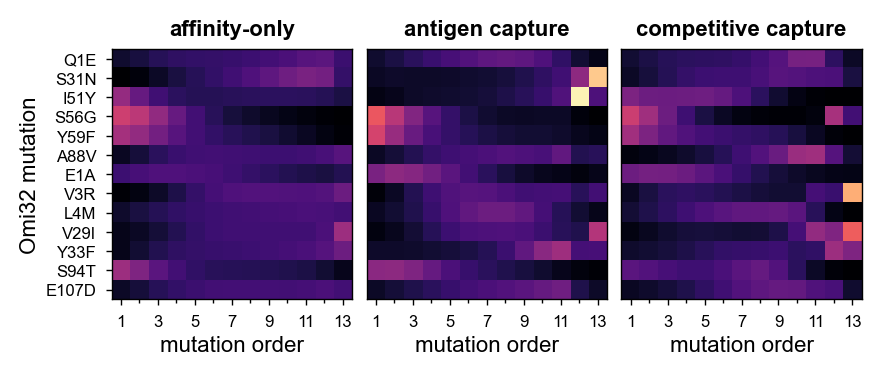

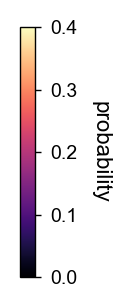

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
import os

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

mpl.rcParams['figure.dpi'] = 200
plt.rcParams.update({
    'font.size': 7,
    'axes.linewidth': 0.5,
    'xtick.major.size': 2,
    'xtick.major.width': 0.5,
    'ytick.major.size': 2,
    'ytick.major.width': 0.5,
    'mathtext.default': 'regular'
})

# Figure configuration

# Canvas size
CANVAS_WIDTH = 3.75
CANVAS_HEIGHT = 1.25

# Margins (in inches)
LEFT_MARGIN = 0.6
RIGHT_MARGIN = 0.2
TOP_MARGIN = 0.175
BOTTOM_MARGIN = 0.35

# Colorbar canvas size
CBAR_CANVAS_WIDTH = 0.075
CBAR_CANVAS_HEIGHT = 1.25

# Colorbar margins
CBAR_LEFT_MARGIN = 0.1
CBAR_RIGHT_MARGIN = 0.3
CBAR_TOP_MARGIN = 0.175
CBAR_BOTTOM_MARGIN = 0.35

# Output DPI
OUTPUT_DPI = 2000

MUTATION_LABELS = [
    'Q1E', 'S31N', 'I51Y', 'S56G', 'Y59F', 'A88V',
    'E1A', 'V3R', 'L4M', 'V29I', 'Y33F', 'S94T', 'E107D'
]
L = 13

affinity_file = '../../pathway_analysis/affinity_only/weak_data/omi-32_probability_ba1_only_affinity_weak.csv'
capture_file = '../../pathway_analysis/antigen_capture/weak_norm_data/omi-32_probability_ba1_only_capture_weak.csv'
competitive_file = '../../pathway_analysis/competitive_antigen_capture/weak_norm_data/omi-32_probability_ba1_only_competitive_capture_weak.csv'

print("Loading mutation order probability data...")
affinity_df = pd.read_csv(affinity_file, index_col=0)
capture_df = pd.read_csv(capture_file, index_col=0)
competitive_df = pd.read_csv(competitive_file, index_col=0)

matrices = [affinity_df.values, capture_df.values, competitive_df.values]
titles = ['affinity-only', 'antigen capture', 'competitive capture']

global_vmax = max([np.nanmax(m) for m in matrices])
print(f"\nGlobal vmax for colorbar: {global_vmax:.3f}")

# Calculate total figure size for main heatmap
fig_width = LEFT_MARGIN + CANVAS_WIDTH + RIGHT_MARGIN
fig_height = TOP_MARGIN + CANVAS_HEIGHT + BOTTOM_MARGIN

# Create main figure with GridSpec
fig = plt.figure(figsize=(fig_width, fig_height))

# Calculate GridSpec parameters to create the canvas area
# For 3 subplots horizontally
gs = GridSpec(1, 3, figure=fig,
              left=LEFT_MARGIN/fig_width,
              right=(LEFT_MARGIN + CANVAS_WIDTH)/fig_width,
              top=1 - TOP_MARGIN/fig_height,
              bottom=BOTTOM_MARGIN/fig_height,
              wspace=0.06)

axes = [fig.add_subplot(gs[0, i]) for i in range(3)]

for idx, (ax, matrix, title) in enumerate(zip(axes, matrices, titles)):
    im = ax.imshow(
        matrix,
        cmap='magma',
        aspect='auto',
        vmin=0,
        vmax=0.4,
        interpolation='nearest'
    )
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    ax.set_xlabel('mutation order', labelpad=2, fontsize=8)
    if idx == 0:
        ax.set_ylabel('Omi32 mutation', labelpad=2, fontsize=8)
    ax.set_title(title, fontsize=8, pad=5, fontweight='bold')

    # x tick configuration
    major_x = [i for i in range(L) if (i + 1) % 2 == 1]
    ax.set_xticks(major_x)
    ax.set_xticklabels([str(i + 1) for i in major_x], fontsize=6)
    
    ax.set_xticks(range(L), minor=True)

    ax.tick_params(axis='x', which='major', bottom=True, top=False,
                   length=2, width=0.5, direction='out', color='black')
    ax.tick_params(axis='x', which='minor', bottom=True, top=False,
                   length=1.5, width=0.5, direction='out', color='black')

    # y tick configuration
    ax.set_yticks(range(L))
    if idx == 0:
        ax.set_yticklabels(MUTATION_LABELS, fontsize=6)
        ax.tick_params(axis='y', which='major', left=True, right=False,
                       length=2, width=0.5, direction='out', color='black')
    else:
        ax.set_yticklabels([])
        ax.tick_params(axis='y', which='major', left=False, right=False, length=0)

    # prevent tick marks being clipped
    for t in ax.xaxis.get_major_ticks():
        t.tick1line.set_clip_on(False)
        t.tick2line.set_clip_on(False)
    for t in ax.xaxis.get_minor_ticks():
        t.tick1line.set_clip_on(False)
        t.tick2line.set_clip_on(False)
    for t in ax.yaxis.get_major_ticks():
        t.tick1line.set_clip_on(False)
        t.tick2line.set_clip_on(False)

# Print main figure size information
print(f'\nMain heatmap:')
print(f'  Canvas size: {CANVAS_WIDTH} × {CANVAS_HEIGHT} inches')
print(f'  Total figure size: {fig_width:.2f} × {fig_height:.2f} inches')
print(f'  At {OUTPUT_DPI} DPI: {int(fig_width * OUTPUT_DPI)} × {int(fig_height * OUTPUT_DPI)} pixels')

os.makedirs('Figure_3d', exist_ok=True)

# Save main heatmap without colorbar
plt.savefig('Figure_3d/Figure_3d.png', dpi=OUTPUT_DPI, bbox_inches='tight', pad_inches=0.02, transparent=True)
print("\n✓ Main heatmap saved successfully!")

# Create separate colorbar figure
cbar_fig_width = CBAR_LEFT_MARGIN + CBAR_CANVAS_WIDTH + CBAR_RIGHT_MARGIN
cbar_fig_height = CBAR_TOP_MARGIN + CBAR_CANVAS_HEIGHT + CBAR_BOTTOM_MARGIN

cbar_fig = plt.figure(figsize=(cbar_fig_width, cbar_fig_height))

# Create GridSpec for colorbar
cbar_gs = GridSpec(1, 1, figure=cbar_fig,
                   left=CBAR_LEFT_MARGIN/cbar_fig_width,
                   right=(CBAR_LEFT_MARGIN + CBAR_CANVAS_WIDTH)/cbar_fig_width,
                   top=1 - CBAR_TOP_MARGIN/cbar_fig_height,
                   bottom=CBAR_BOTTOM_MARGIN/cbar_fig_height)

cbar_ax = cbar_fig.add_subplot(cbar_gs[0])

# Create colorbar
cbar = cbar_fig.colorbar(im, cax=cbar_ax)
cbar.set_label('probability', rotation=270, labelpad=12, fontsize=8)
cbar.outline.set_linewidth(0.5)
cbar.set_ticks([0.0, 0.1, 0.2, 0.3, 0.4])
cbar.ax.tick_params(length=2, width=0.5, direction='out', color='black')
cbar.set_ticklabels(['0.0', '0.1', '0.2', '0.3', '0.4'])

# Print colorbar figure size information
print(f'\nColorbar:')
print(f'  Canvas size: {CBAR_CANVAS_WIDTH} × {CBAR_CANVAS_HEIGHT} inches')
print(f'  Total figure size: {cbar_fig_width:.2f} × {cbar_fig_height:.2f} inches')
print(f'  At {OUTPUT_DPI} DPI: {int(cbar_fig_width * OUTPUT_DPI)} × {int(cbar_fig_height * OUTPUT_DPI)} pixels')

# Save colorbar
plt.figure(cbar_fig.number)
plt.savefig('Figure_3d/Figure_3d_colorbar.png', dpi=OUTPUT_DPI, bbox_inches='tight', pad_inches=0.02, transparent=True)
print("\n✓ Colorbar saved successfully!")

plt.show()